Radio Materials in scene: ['Glass']

Testing Frequency: 450M


<Figure size 800x1000 with 0 Axes>

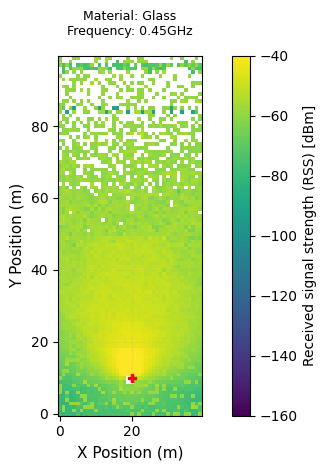


Testing Frequency: 700M


<Figure size 800x1000 with 0 Axes>

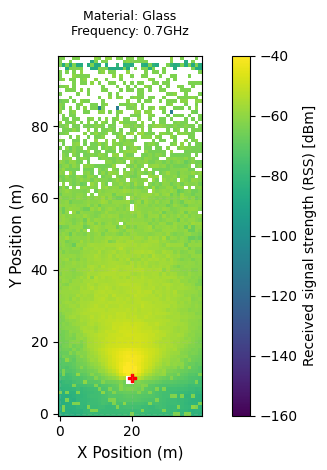


Testing Frequency: 900M


<Figure size 800x1000 with 0 Axes>

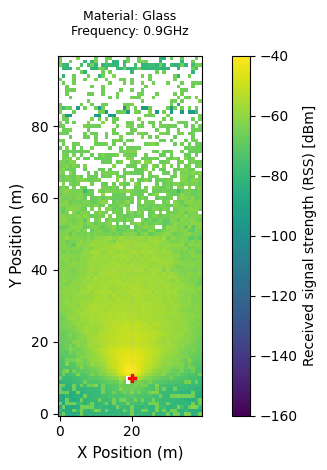


Testing Frequency: 1.5G


<Figure size 800x1000 with 0 Axes>

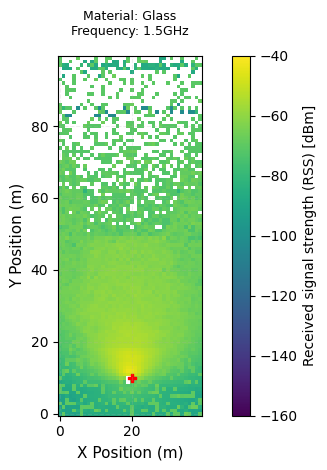


Testing Frequency: 2.1G


<Figure size 800x1000 with 0 Axes>

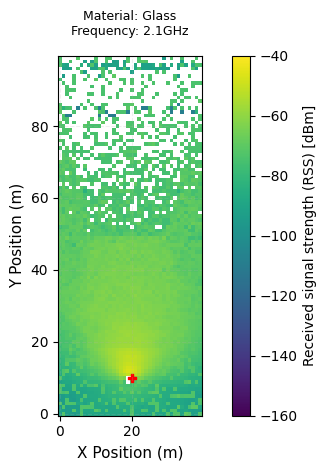


Testing Frequency: 2.5G


<Figure size 800x1000 with 0 Axes>

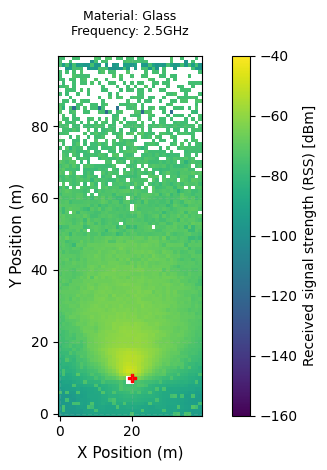


Testing Frequency: 3.5G


<Figure size 800x1000 with 0 Axes>

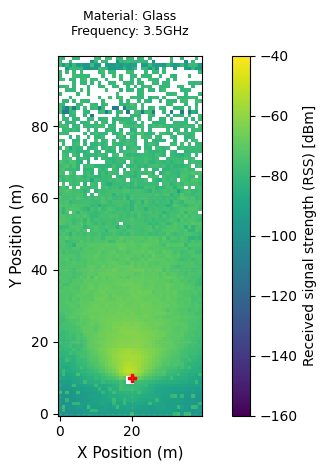


Testing Frequency: 4.5G


<Figure size 800x1000 with 0 Axes>

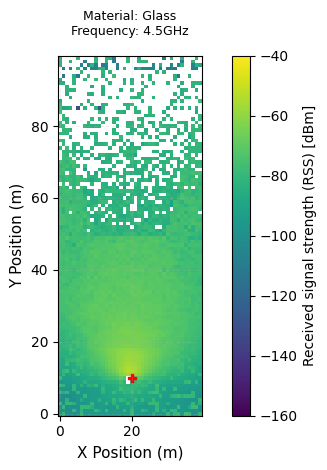


Testing Frequency: 6G


<Figure size 800x1000 with 0 Axes>

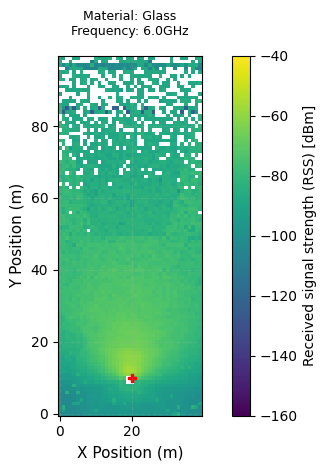


Testing Frequency: 10G


<Figure size 800x1000 with 0 Axes>

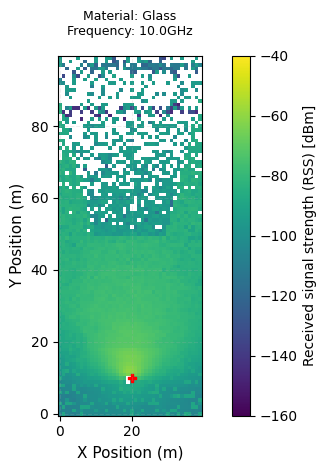


Testing Frequency: 28G


<Figure size 800x1000 with 0 Axes>

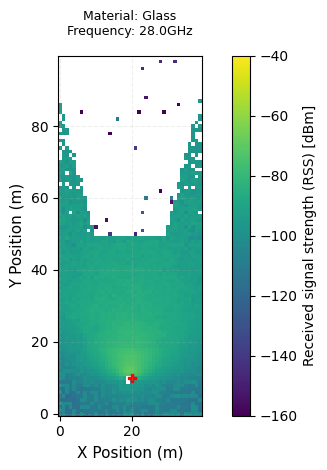


Testing Frequency: 35G


<Figure size 800x1000 with 0 Axes>

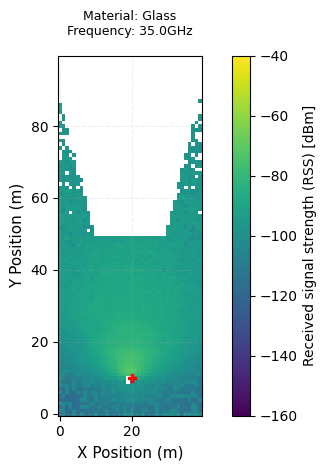

Frequency: 450M, RSS = [-62.171814] dBm
Frequency: 700M, RSS = [-62.77891] dBm
Frequency: 900M, RSS = [-62.008064] dBm
Frequency: 1.5G, RSS = [-66.966896] dBm
Frequency: 2.1G, RSS = [-70.58682] dBm
Frequency: 2.5G, RSS = [-82.00489] dBm
Frequency: 3.5G, RSS = [-81.01307] dBm
Frequency: 4.5G, RSS = [-81.67861] dBm
Frequency: 6G, RSS = [-80.48494] dBm
Frequency: 10G, RSS = [-100.747215] dBm
Frequency: 28G, RSS = [-136.49324] dBm
Frequency: 35G, RSS = [-157.17908] dBm


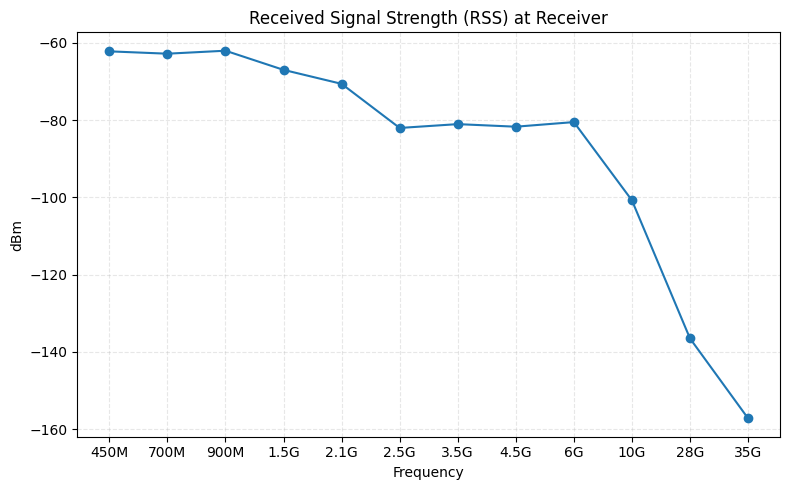

In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver
import matplotlib.pyplot as plt

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/wall.xml")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add material to scene
scene.add(ITURadioMaterial(
    name="Glass",
    itu_type="glass",
    thickness=0.1
))

# Apply material to wall and plane object
scene.objects["Cube"].radio_material = "Glass"
scene.objects["Plane"].radio_material = "Glass"

scene.remove("itu-very_dry_ground")
scene.remove("itu-concrete")

# Check current material in the scene
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Deploy Tx and Rx location
tx = Transmitter("tx", [0, -40, 1.5], [0, 0,0], power_dbm=0)
rx = Receiver("rx", [0, 40, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Define frequencies to test
frequencies = [
    0.45e9,
    0.7e9,
    0.9e9,
    1.5e9,
    2.1e9,
    2.5e9,
    3.5e9,
    4.5e9,
    6e9,
    10e9,
    28e9,
    35e9,
]

frequency_labels = [
    "450M",
    "700M",
    "900M",
    "1.5G",
    "2.1G",
    "2.5G",
    "3.5G",
    "4.5G",
    "6G",
    "10G",
    "28G",
    "35G"
]

# Generate radio map
rm_solver = RadioMapSolver()

for freq, label in zip(frequencies, frequency_labels):

    # Set scene frequency
    scene.frequency = freq

    print(f"\nTesting Frequency: {label}")

    rm = rm_solver(
        scene,
        max_depth=10,
        samples_per_tx=10**7,
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[40, 100],
        orientation=[0, 0, 0]
    )

    plt.figure(figsize=(8, 10))

    # Show radio map
    rm.show(metric="rss")

    plt.title(
        f"Material: Glass\n"
        f"Frequency: {freq/1e9}GHz",
        fontsize=9,
        pad=15
    )

    plt.xlabel("X Position (m)", fontsize=11)
    plt.ylabel("Y Position (m)", fontsize=11)
    plt.clim(-160, -40)
    plt.grid(
        alpha=0.2,
        linestyle="--"
    )
    plt.tight_layout()
    plt.show()

# Generate paths
p_solver = PathSolver()

rss_results = []

for freq, label in zip(frequencies, frequency_labels):

    scene.frequency = freq

    paths = p_solver(
        scene,
        max_depth=10,
        samples_per_src=10**6
    )

    a = paths.a[0].numpy().flatten()

    power = np.abs(a)**2

    if power.size == 0:
        print(f"No paths for {label}")
        rss_results.append(np.nan)
        continue

    rss = 10 * np.log10(np.sum(power)) + tx.power_dbm

    rss_results.append(rss)

    print(f"Frequency: {label}, RSS = {rss} dBm")

plt.figure(figsize=(8,5))

plt.plot(
    frequency_labels,
    rss_results,
    marker='o'
)

plt.xlabel("Frequency")
plt.ylabel("dBm")
plt.title("Received Signal Strength (RSS) at Receiver")

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()
plt.show()